In [5]:
import pandas as pd
import phunk
import requests
import io
import matplotlib.pyplot as plt

from socca_tune.initialize import initialize

In [6]:
target = "Eugenia"

# get data for target
r = requests.post(
    "https://api.ztf.fink-portal.org/api/v1/sso",
    json={
        "n_or_d": f"{target}",
        "withEphem": True,
        "withResiduals": True,
        "output-format": "json",
    },
)

# Format output in a DataFrame
data = pd.read_json(io.BytesIO(r.content))

In [7]:
pc = phunk.PhaseCurve(
    target=target,
    epoch=data["Date"],
    phase=data["Phase"],
    mag=data["i:magpsf_red"],
    mag_err=data["i:sigmapsf"],
    band=data["i:fid"],
)
pc.get_ephems()
pc.epoch = pc.epoch_ltc  # Light-time corrected epochs

Querying ephemerides via IMCCE Miriade..


In [8]:
p0, metadata = initialize(pc, weights=pc.mag_err, remap=True, metadata=False)
pc.fit(models=["SOCCA"], p0=p0, weights=pc.mag_err, remap=True)

In [9]:
import rocks

rock = rocks.Rock(target)

print(f"{'Parameter':<13} {'rocks':>12} {'SOCCA':>19}")
print("-" * 50)

rock_vals = {
    "RA": rock.parameters.physical.spin.RA0.value[0],
    "DEC": rock.parameters.physical.spin.DEC0.value[0],
    "Period": rock.parameters.physical.spin.period.value[0],
}

socca_vals = {
    "RA": pc.SOCCA.alpha,
    "DEC": pc.SOCCA.delta,
    "Period": pc.SOCCA.period * 24,
}

for key in rock_vals:
    print(f"{key:<10} {rock_vals[key]:19.6f} {socca_vals[key]:19.6f}")

Parameter            rocks               SOCCA
--------------------------------------------------
RA                  121.039000          119.185747
DEC                 -16.015000          -19.502728
Period                5.699152            5.699136


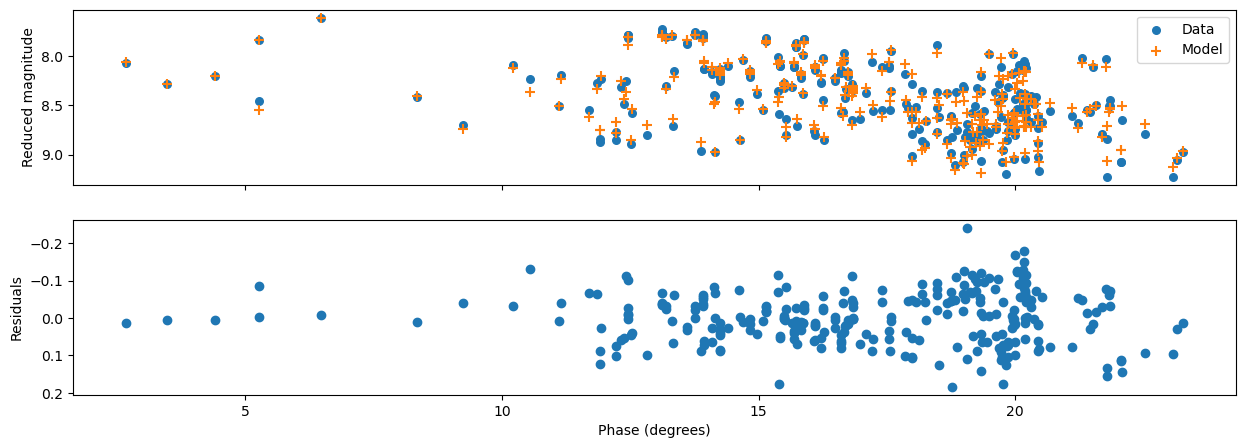

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(15, 5), sharex=True)

x = data["Phase"]
obs = data["i:magpsf_red"]
model_SOCCA = pc.SOCCA.eval(pc)

ax[0].scatter(x, obs, label="Data", s=30)
ax[0].scatter(x, model_SOCCA, marker="+", label="Model", s=60)
ax[0].legend()
ax[0].set_ylabel("Reduced magnitude")

ax[1].scatter(x, obs - model_SOCCA)
ax[1].set_ylabel("Residuals")

ax[1].set_xlabel("Phase (degrees)")
for a in ax:
    a.invert_yaxis()

In [11]:
from phunk.equations import rotation_phase, subobserver_longitude, cos_aspect_angle
import numpy as np

W0 = np.radians(pc.SOCCA.W0)
W1 = 2 * np.pi / pc.SOCCA.period
t0 = 2459580.5


rot_phase = rotation_phase(pc.epoch, W0, W1, t0)


sep_long = subobserver_longitude(
    np.radians(pc.ra),
    np.radians(pc.dec),
    np.radians(pc.SOCCA.alpha),
    np.radians(pc.SOCCA.delta),
    rot_phase,
) % (2 * np.pi)


aspect = cos_aspect_angle(
    np.radians(pc.ra),
    np.radians(pc.dec),
    np.radians(pc.SOCCA.alpha),
    np.radians(pc.SOCCA.delta),
)


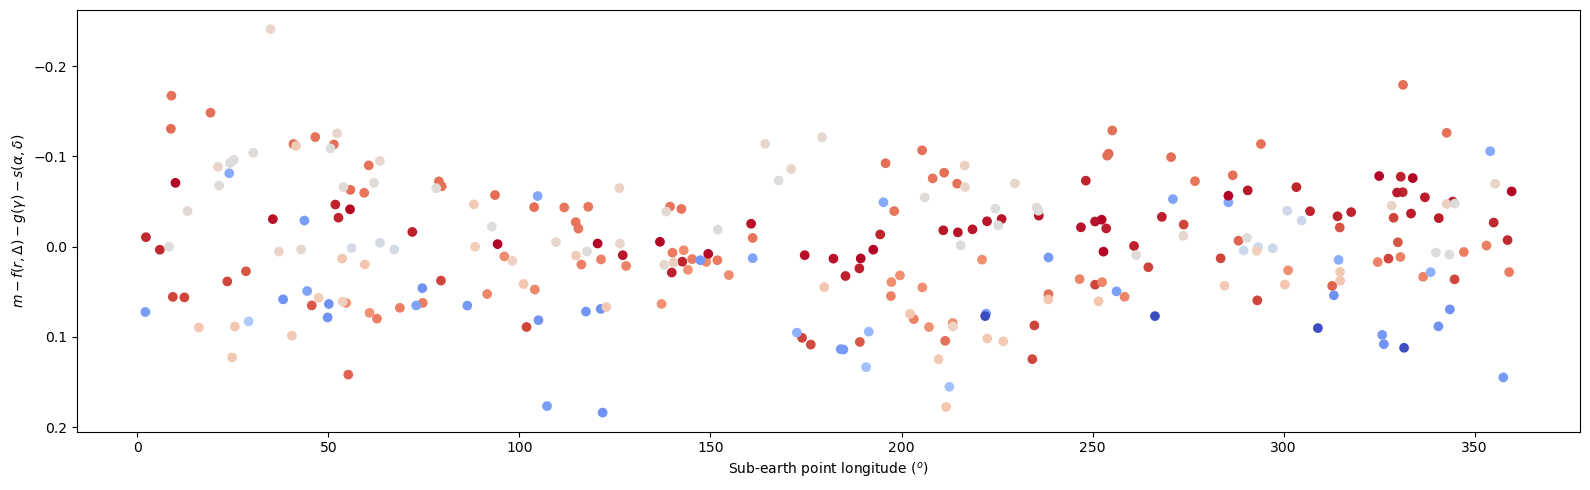

In [12]:
fig, ax = plt.subplots(figsize=(16, 5), sharex=True, sharey=True)

ax.scatter(np.degrees(sep_long), pc.mag - model_SOCCA, c=aspect, cmap="coolwarm")

ax.set_ylabel(r"$m - f(r, \Delta) - g(\gamma) - s(\alpha, \delta)$")

ax.invert_yaxis()
ax.set_xlabel("Sub-earth point longitude ($^o$)")
fig.tight_layout()
